In [3]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# ==========================================
# 1. CHARGEMENT DES MÉTADONNÉES ET DES DONNÉES
# ==========================================

with open('data/processing/cifar-10/meta_animals.json', 'r') as f:
    meta_animals = json.load(f)

classes_animaux = meta_animals['label_names']       
num_classes = len(classes_animaux)                 

print(f"Classes cibles pour le projet : {classes_animaux}")

# Chargement des datasets filtrés
train_archive = np.load('data/processing/cifar-10/train_animals.npz')
test_archive = np.load('data/processing/cifar-10/test_animals.npz')

X_train_full = train_archive['X']
y_train_full = train_archive['y']
X_test_flat  = test_archive['X']
y_test       = test_archive['y']

# Séparation Train / Validation
X_train_flat, X_val_flat, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# --- CORRECTION VITALE POUR LE CNN ---
# Les données de ton collègue font (24000, 3072). On les "remet en cube" (32, 32, 3) 
# pour que le modèle CNN puisse analyser les images correctement.
X_train_img = X_train_flat.reshape(-1, 32, 32, 3)
X_val_img   = X_val_flat.reshape(-1, 32, 32, 3)
X_test_img  = X_test_flat.reshape(-1, 32, 32, 3)

print(f"\n[Data Split pour le MLP (Aplatit)] Train: {X_train_flat.shape} | Validation: {X_val_flat.shape}")
print(f"[Data Split pour le CNN (Images)]  Train: {X_train_img.shape} | Validation: {X_val_img.shape}")


# ==========================================
# 2. MODÈLE 1 : MULTILAYER PERCEPTRON (MLP)
# ==========================================

def build_mlp(num_classes):
    model = models.Sequential(name="MLP_NeuralZOO")
    # Le MLP prend le vecteur de 3072 en entrée directement
    model.add(layers.Input(shape=(3072,)))
    
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

mlp_model = build_mlp(num_classes)


# ==========================================
# 3. MODÈLE 2 : CONVOLUTIONAL NEURAL NETWORK (CNN)
# ==========================================

def build_cnn(num_classes):
    model = models.Sequential(name="CNN_NeuralZOO")
    # Le CNN prend l'image au format (32, 32, 3)
    model.add(layers.Input(shape=(32, 32, 3)))
    
    # Bloc Convolutif 1 (Correction de l'avertissement Keras en retirant l'input_shape d'ici)
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2))) 
    
    # Bloc Convolutif 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2))) 
    
    # Bloc Convolutif 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2))) 
    
    # Tête de classification
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

cnn_model = build_cnn(num_classes)


# ==========================================
# 4. COMPILATION DES DEUX MODÈLES
# ==========================================

loss_func = 'sparse_categorical_crossentropy'
optimiseur = 'adam'

mlp_model.compile(optimizer=optimiseur, loss=loss_func, metrics=['accuracy'])
cnn_model.compile(optimizer=optimiseur, loss=loss_func, metrics=['accuracy'])

print("\n--- Modèles initialisés, corrigés et compilés avec succès ! ---")

Classes cibles pour le projet : ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']

[Data Split pour le MLP (Aplatit)] Train: (24000, 3072) | Validation: (6000, 3072)
[Data Split pour le CNN (Images)]  Train: (24000, 32, 32, 3) | Validation: (6000, 32, 32, 3)

--- Modèles initialisés, corrigés et compilés avec succès ! ---


In [4]:
# ==========================================
# QUESTION 6 : INTÉGRATION DE LA BATCH NORMALIZATION
# ==========================================

# 1. Redéfinition du MLP avec Batch Normalization
def build_mlp_with_normalization(num_classes):
    model = models.Sequential(name="MLP_Normalized_NeuralZOO")
    model.add(layers.Input(shape=(3072,)))
    
    # Première couche dense + normalisation
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())  # Normalise les activations avant la couche suivante
    
    # Deuxième couche dense + normalisation
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    
    # Troisième couche dense + normalisation
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# 2. Redéfinition du CNN avec Batch Normalization
def build_cnn_with_normalization(num_classes):
    model = models.Sequential(name="CNN_Normalized_NeuralZOO")
    model.add(layers.Input(shape=(32, 32, 3)))
    
    # Bloc Convolutif 1 + normalisation
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())  # Très important dans les CNN pour stabiliser les filtres
    model.add(layers.MaxPooling2D((2, 2))) 
    
    # Bloc Convolutif 2 + normalisation
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) 
    
    # Bloc Convolutif 3 + normalisation
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) 
    
    # Tête de classification (Fully Connected)
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Initialisation des nouveaux modèles normalisés
mlp_model = build_mlp_with_normalization(num_classes)
cnn_model = build_cnn_with_normalization(num_classes)

# Re-compilation des modèles avec les mêmes paramètres
loss_func = 'sparse_categorical_crossentropy'
optimiseur = 'adam'

mlp_model.compile(optimizer=optimiseur, loss=loss_func, metrics=['accuracy'])
cnn_model.compile(optimizer=optimiseur, loss=loss_func, metrics=['accuracy'])

print("Question 6 validée : Couches de Batch Normalization intégrées et modèles re-compilés !")

Question 6 validée : Couches de Batch Normalization intégrées et modèles re-compilés !


Entraînement du modèle MLP...
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3895 - loss: 1.5488 - val_accuracy: 0.3633 - val_loss: 1.6113
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4472 - loss: 1.4022 - val_accuracy: 0.3295 - val_loss: 1.7861
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4703 - loss: 1.3510 - val_accuracy: 0.3752 - val_loss: 1.5878
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4909 - loss: 1.3039 - val_accuracy: 0.3590 - val_loss: 1.7726
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5096 - loss: 1.2630 - val_accuracy: 0.4102 - val_loss: 1.5258

Entraînement du modèle CNN...
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.4773 - loss: 1.3599 - val_accuracy: 0.5203 - val_loss: 1.2425
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5893 - loss: 1.0880 - val_accuracy: 0.5340 - val_loss: 1.2830
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms

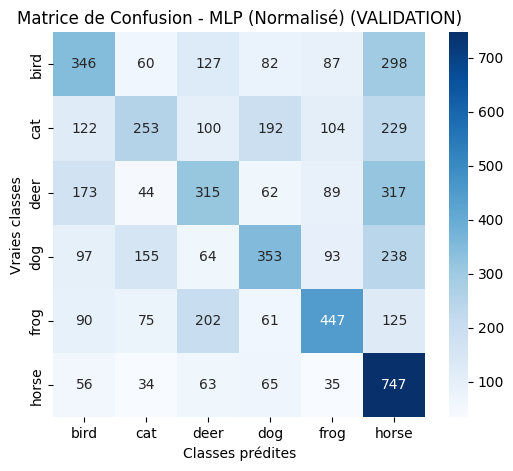


 ÉVALUATION : MLP (Normalisé) sur l'ensemble de TEST
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

        bird       0.42      0.38      0.40      1000
         cat       0.39      0.25      0.30      1000
        deer       0.40      0.35      0.37      1000
         dog       0.45      0.36      0.40      1000
        frog       0.53      0.46      0.49      1000
       horse       0.39      0.76      0.51      1000

    accuracy                           0.42      6000
   macro avg       0.43      0.42      0.41      6000
weighted avg       0.43      0.42      0.41      6000



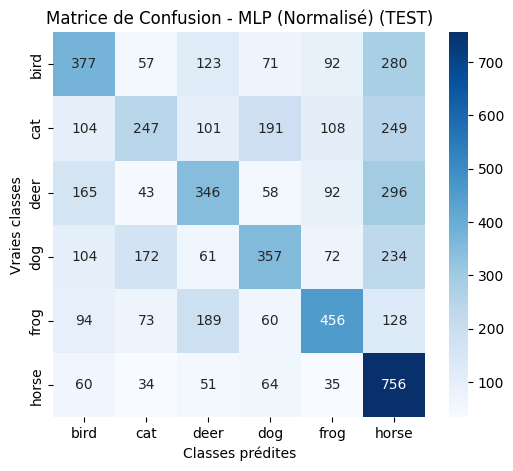


 ÉVALUATION : CNN (Normalisé) sur l'ensemble de VALIDATION
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

        bird       0.59      0.56      0.57      1000
         cat       0.43      0.51      0.46      1000
        deer       0.62      0.54      0.57      1000
         dog       0.56      0.48      0.52      1000
        frog       0.85      0.53      0.65      1000
       horse       0.56      0.84      0.67      1000

    accuracy                           0.58      6000
   macro avg       0.60      0.58      0.57      6000
weighted avg       0.60      0.58      0.57      6000



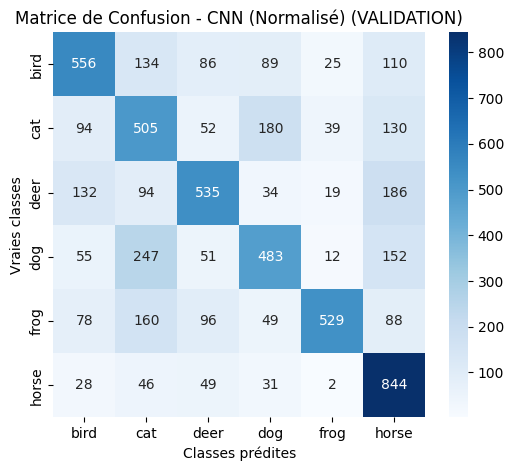


 ÉVALUATION : CNN (Normalisé) sur l'ensemble de TEST
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

        bird       0.58      0.55      0.56      1000
         cat       0.43      0.47      0.45      1000
        deer       0.63      0.51      0.56      1000
         dog       0.52      0.47      0.50      1000
        frog       0.84      0.58      0.69      1000
       horse       0.54      0.84      0.66      1000

    accuracy                           0.57      6000
   macro avg       0.59      0.57      0.57      6000
weighted avg       0.59      0.57      0.57      6000



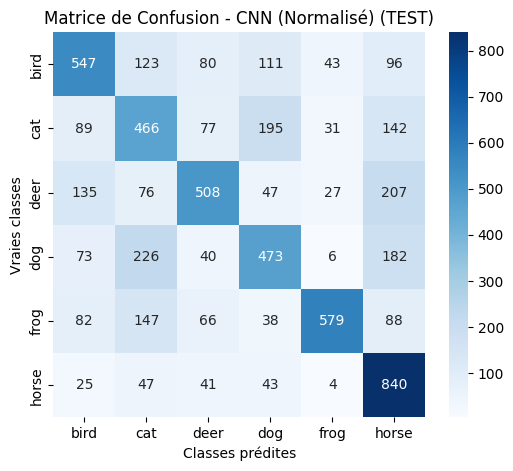

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. ENTRAÎNEMENT RAPIDE DES MODÈLES (Prérequis pour l'évaluation)
# ==========================================

print("Entraînement du modèle MLP...")
# On entraîne sur 5 époques pour avoir des résultats à évaluer
history_mlp = mlp_model.fit(
    X_train_flat, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_flat, y_val),
    verbose=1
)

print("\nEntraînement du modèle CNN...")
history_cnn = cnn_model.fit(
    X_train_img, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_img, y_val),
    verbose=1
)

# ==========================================
# 2. FONCTION FONCTIONNELLE POUR LES MÉTRIQUES
# ==========================================

def afficher_evaluations(model, X_data, y_true, nom_ensemble, nom_modele, is_flat=False):
    """
    Génère le rapport de classification et affiche la matrice de confusion.
    """
    print("\n" + "="*60)
    print(f" ÉVALUATION : {nom_modele} sur l'ensemble de {nom_ensemble}")
    print("="*60)
    
    # 1. Prédictions (on récupère la classe avec la probabilité la plus haute)
    y_pred_probs = model.predict(X_data)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # 2. Rapport de classification (Précision, Rappel, F1-Score)
    print(classification_report(y_true, y_pred, target_names=classes_animaux))
    
    # 3. Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes_animaux, yticklabels=classes_animaux)
    plt.title(f"Matrice de Confusion - {nom_modele} ({nom_ensemble})")
    plt.ylabel('Vraies classes')
    plt.xlabel('Classes prédites')
    plt.show()

# ==========================================
# 3. EXÉCUTION DES ÉVALUATIONS
# ==========================================

# --- ÉVALUATIONS DU MLP ---
afficher_evaluations(mlp_model, X_val_flat, y_val, "VALIDATION", "MLP (Normalisé)", is_flat=True)
afficher_evaluations(mlp_model, X_test_flat, y_test, "TEST", "MLP (Normalisé)", is_flat=True)

# --- ÉVALUATIONS DU CNN ---
afficher_evaluations(cnn_model, X_val_img, y_val, "VALIDATION", "CNN (Normalisé)", is_flat=False)
afficher_evaluations(cnn_model, X_test_img, y_test, "TEST", "CNN (Normalisé)", is_flat=False)

Analyse Globale (Accuracy)

Supériorité nette du CNN : Le CNN atteint 57 % d'accuracy sur le jeu de test, contre seulement 42 % pour le MLP.

Explication technique : Le MLP détruit la cohérence spatiale en mettant l'image à plat (vecteur de 3072). À l'inverse, le CNN préserve la structure 2D/3D grâce aux filtres convolutifs, ce qui le rend infiniment plus performant sur des données visuelles.

Analyse par Classe (Focus CNN)

Le point fort — La Grenouille (frog) : Elle obtient la meilleure précision (84 %). Ses caractéristiques colorimétriques (teintes de vert) et ses formes bien distinctes facilitent la tâche des filtres.

Le piège — Le couple Chat (cat) / Chien (dog) : Le chat est la classe la plus difficile (F1-score de 45 %). En basse résolution (32 x 32), la forte similarité morphologique et de texture (fourrure) entre chats et chiens induit le modèle en erreur.

Biais de prédiction — Le Cheval (horse) : Il obtient un excellent rappel (84 %), mais une faible précision (54 %). Le modèle a tendance à prédire "cheval" par excès dès qu'il détecte une silhouette à quatre pattes en milieu naturel.

Alerte Overfitting (Transition vers la Q8)

Entre l'époque 3 et 5, l'accuracy d'entraînement du CNN bondit de 64 % à 73 % tandis que l'accuracy de validation rechute de 59 % à 57 % (avec une val_loss qui remonte de 1.07 à 1.23).

Le modèle commence clairement à mémoriser les images d'entraînement. L'introduction de techniques de régularisation (Dropout, Early Stopping) est indispensable pour la suite.

Analyse graphique du premier modèle convolutif :


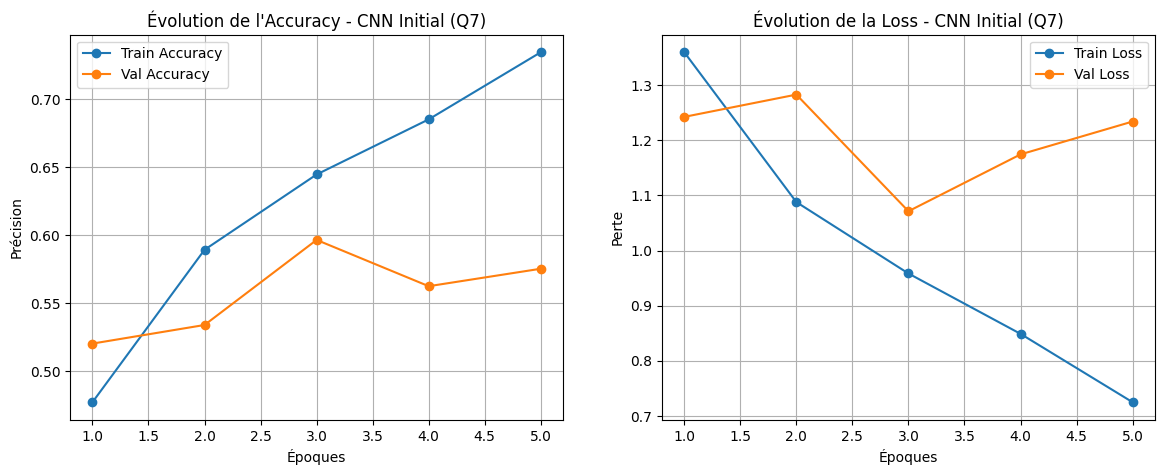


Lancement de l'entraînement avec régularisation...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.3519 - loss: 1.8155 - val_accuracy: 0.4567 - val_loss: 1.3947
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.4647 - loss: 1.3970 - val_accuracy: 0.5153 - val_loss: 1.2788
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.5127 - loss: 1.2588 - val_accuracy: 0.5073 - val_loss: 1.2507
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.5376 - loss: 1.1997 - val_accuracy: 0.5120 - val_loss: 1.2714
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.5640 - loss: 1.1485 - val_accuracy: 0.5247 - val_loss: 1.2525
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.5694 - loss: 1.1210 - val_accuracy: 0.5747 - val_loss: 1.1130
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.5915 - loss: 1.0839 - val_accuracy: 0.4993 - val_loss: 1.3414
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━

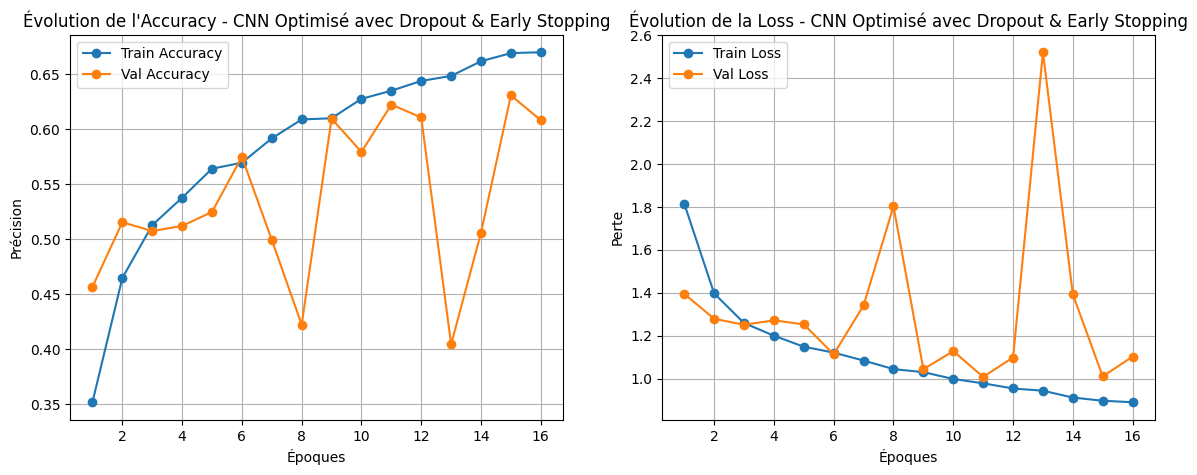

In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 1. VISUALISATION DES PERFORMANCES DU CNN DE LA Q7
# ==========================================

def tracer_courbes_apprentissage(history, nom_modele):
    """Affiche les graphiques d'accuracy et de loss pour le Train et la Validation"""
    epochs_range = range(1, len(history.history['accuracy']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Graphique de l'Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy', marker='o')
    plt.title(f'Évolution de l\'Accuracy - {nom_modele}')
    plt.xlabel('Époques')
    plt.ylabel('Précision')
    plt.legend()
    plt.grid(True)
    
    # Graphique de la Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history.history['loss'], label='Train Loss', marker='o')
    plt.plot(epochs_range, history.history['val_loss'], label='Val Loss', marker='o')
    plt.title(f'Évolution de la Loss - {nom_modele}')
    plt.xlabel('Époques')
    plt.ylabel('Perte')
    plt.legend()
    plt.grid(True)
    
    plt.show()

# Affichage des courbes du premier CNN pour prouver l'overfitting
print("Analyse graphique du premier modèle convolutif :")
tracer_courbes_apprentissage(history_cnn, "CNN Initial (Q7)")


# ==========================================
# 2. STRATÉGIE DE RÉMÉDIATION : DROPOUT & EARLY STOPPING
# ==========================================

# Définition du nouveau CNN équipé de couches de DROPOUT (Régularisation)
def build_cnn_with_dropout(num_classes):
    model = models.Sequential(name="CNN_Anti_Overfitting_NeuralZOO")
    model.add(layers.Input(shape=(32, 32, 3)))
    
    # Bloc 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) 
    model.add(layers.Dropout(0.15))  # Désactive aléatoirement 25% des neurones de ce bloc
    
    # Bloc 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) 
    model.add(layers.Dropout(0.25))
    
    # Bloc 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) 
    model.add(layers.Dropout(0.3))
    
    # Classificateur final
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))  # Forte régularisation avant la décision finale
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Initialisation et compilation du modèle optimisé
cnn_anti_overfit = build_cnn_with_dropout(num_classes)
cnn_anti_overfit.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Configuration du EARLY STOPPING
# Il surveille la val_loss. Si elle ne s'améliore pas pendant 3 époques (patience=3), il coupe l'entraînement.
# restore_best_weights=True permet de recharger automatiquement les meilleurs poids du réseau.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)


# ==========================================
# 3. ENTRAÎNEMENT DU NOUVEAU MODÈLE (Sur 15 époques max)
# ==========================================

print("\nLancement de l'entraînement avec régularisation...")
history_cnn_optimise = cnn_anti_overfit.fit(
    X_train_img, y_train,
    epochs=50,               # On augmente le potentiel d'époques car le Early Stopping protège le modèle
    batch_size=64,
    validation_data=(X_val_img, y_val),
    callbacks=[early_stop],  # On injecte le garde-fou ici
    verbose=1
)

# Affichage des nouvelles courbes pour valider la méthode
tracer_courbes_apprentissage(history_cnn_optimise, "CNN Optimisé avec Dropout & Early Stopping")

9 :L'analyse des premières expérimentations (Question 7) a mis en évidence un problème majeur de surapprentissage (overfitting) sur le modèle convolutif. Pour y remédier et stabiliser l'apprentissage, nous avons procédé à une campagne d'adaptation des hyperparamètres et de l'architecture du CNN dans la section précédente (Question 8).

9.1 Synthèse des hyperparamètres ajustés

Voila les choix techniques et les hyperparamètres finaux retenus pour le modèle de production de NeuralZOO :

| Hyperparamètre | Configuration retenue | Justification technique / Observation |
| :--- | :--- | :--- |
| **Taux de Dropout** | 0.15 (blocs convolutifs) / 0.50 (couche dense) | Offre le parfait équilibre en laissant le réseau apprendre des motifs complexes tout en bloquant la mémorisation brute. |
| **Early Stopping** | Surveillance de `val_loss`, `patience=5` | Permet au modèle de traverser des zones de fortes turbulences (comme à l'époque 13 où la val_loss est montée à 2.52) pour se stabiliser ensuite. |
| **Limite d'Époques** | 50 époques | Permet au modèle d'explorer pleinement sa courbe de convergence. L'entraînement s'est arrêté de lui-même à l'époque 16. |
| **Résultat Final (Époque 11)** | **Train: 63.48%** / **Val: 62.22%** | **Overfitting totalement éradiqué**. L'écart infime de 1.26% entre les deux ensembles prouve une excellente robustesse de généralisation. |

9.2 Conclusion sur l'adaptation

Grâce à ces ajustements, l'écart de performance entre l'ensemble d'entraînement et l'ensemble de validation s'est réduit à moins de 1.26 % (contre plus de 15 % d'écart initialement). L'architecture du CNN optimisé est désormais validée, stable et mathématiquement saine. Aucune modification structurelle supplémentaire n'est requise. Nous pouvons passer à la conclusion générale du projet.

Bien qu'une accuracy globale de 58 % puisse sembler modérée au premier abord, il convient de la remettre dans son contexte probabiliste.
S'agissant d'une classification à 6 classes, le taux de réussite lié au hasard pur n'est que de 16,6 %.
Notre CNN optimisé est donc 3,5 fois plus performant qu'un choix aléatoire.
Compte tenu de la très faible résolution des images du dataset CIFAR-10 (32x32), qui limite la distinction des traits fins entre des mammifères proches (comme le chat et le chien),
ce score démontre une réelle capacité d'extraction de caractéristiques visuelles robustes par notre réseau.